In [44]:
from dotenv import load_dotenv
load_dotenv()

True

In [45]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command
from typing import Literal

In [46]:
llm = ChatGroq(
    model = "openai/gpt-oss-20b"
)

In [47]:
class MailState(BaseModel) : 
    query : str = Field(default="", description="User query")
    draft : str = Field(default="", description="Response which will be reviewed by the user")
    human_feedback : str = Field(default="", description="User feedback on the draft")
    final_response : str = Field(default="", description="Final Answer")

In [48]:
## Defining the nodes 
def DraftEmail(state : MailState) -> MailState : 
    if state.human_feedback : 
        draft = llm.invoke(f"""
        You have generated this mail : {state.draft}.
        Human feedback to apply : {state.human_feedback}. 
        Rewrite this draft email for {state.query}
        """).content
    else : 
        draft = llm.invoke(state.query).content
        
    state.draft = draft
    return state

def HumanFeedback(state : MailState) -> MailState : 
    feedback = interrupt({
        "draft_email" : state.draft, 
        "question" : "Do you want to continue or re-write the mail?"
    })

    fb = (feedback or "").strip().lower()
    if fb in ("approved", "ok", "yes") : 
        state.human_feedback = ""
        return state
    else : 
        state.human_feedback = feedback
        return state

def finalize_node(state : MailState) -> MailState : 
    if state.human_feedback : 
        state.final_response = state.human_feedback 
        return state
    else : 
        print("Email Sent successfully....")
        state.final_response = "Email Sent Successfully"
        return state

def condition_routing(state : MailState) -> Literal["DraftEmail", "finalize_node"] : 
    if state.human_feedback : 
        return "DraftEmail"

    return "finalize_node"

In [49]:
graph_builder = StateGraph(MailState)

graph_builder.add_node("DraftEmail", DraftEmail)
graph_builder.add_node("HumanFeedback", HumanFeedback)
graph_builder.add_node("finalize_node", finalize_node)

graph_builder.add_edge(START, "DraftEmail")
graph_builder.add_edge("DraftEmail", "HumanFeedback")
graph_builder.add_conditional_edges("HumanFeedback", condition_routing)
graph_builder.add_edge("finalize_node", END)

graph = graph_builder.compile(checkpointer=InMemorySaver())

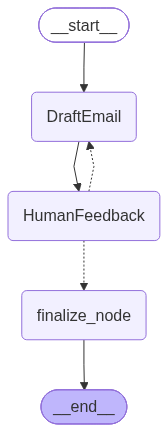

In [50]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [56]:
config = {"configurable" : {"thread_id" : "1"}}

In [57]:
res = graph.invoke({"query" : "I want to send an email for medical leave request , dates will be 3nd June to 5th June. So create a simple mail."}, config=config)

In [59]:
print(res["draft"])

**Subject:** Medical Leave Request – 3 June to 5 June

Dear [Supervisor’s Name],

I am writing to request medical leave from **Monday, 3 June** through **Wednesday, 5 June**. I have been advised by my doctor to rest during this period to ensure a full recovery.

I will ensure that all urgent tasks are delegated and that my responsibilities are covered during my absence. Please let me know if you need any additional documentation or if there are specific procedures I should follow.

Thank you for your understanding and support.

Best regards,  
[Your Name]  
[Your Position]  
[Your Contact Information]


In [60]:
res = graph.invoke(Command(resume="i want to change the leave dates, and new dates are : 4th June to 7th June ; and I want to remove the placeholders and just say thank you"), config=config)

In [61]:
print(res["draft"])

**Subject:** Medical Leave Request – 4 June to 7 June  

Dear Supervisor,

I am writing to request medical leave from **4 June** to **7 June**. My doctor has advised me to rest during this period to ensure a full recovery.

I will ensure that all urgent tasks are delegated and covered during my absence.

Thank you.


In [62]:
res 

{'query': 'I want to send an email for medical leave request , dates will be 3nd June to 5th June. So create a simple mail.',
 'draft': '**Subject:** Medical Leave Request – 4\u202fJune\u202fto\u202f7\u202fJune  \n\nDear Supervisor,\n\nI am writing to request medical leave from **4\u202fJune** to **7\u202fJune**. My doctor has advised me to rest during this period to ensure a full recovery.\n\nI will ensure that all urgent tasks are delegated and covered during my absence.\n\nThank you.',
 'human_feedback': 'i want to change the leave dates, and new dates are : 4th June to 7th June ; and I want to remove the placeholders and just say thank you',
 'final_response': '',
 '__interrupt__': [Interrupt(value={'draft_email': '**Subject:** Medical Leave Request – 4\u202fJune\u202fto\u202f7\u202fJune  \n\nDear Supervisor,\n\nI am writing to request medical leave from **4\u202fJune** to **7\u202fJune**. My doctor has advised me to rest during this period to ensure a full recovery.\n\nI will ensu

In [63]:
res = graph.invoke(Command(resume="yes"), config = config)

Email Sent successfully....


In [64]:
res

{'query': 'I want to send an email for medical leave request , dates will be 3nd June to 5th June. So create a simple mail.',
 'draft': '**Subject:** Medical Leave Request – 4\u202fJune\u202fto\u202f7\u202fJune  \n\nDear Supervisor,\n\nI am writing to request medical leave from **4\u202fJune** to **7\u202fJune**. My doctor has advised me to rest during this period to ensure a full recovery.\n\nI will ensure that all urgent tasks are delegated and covered during my absence.\n\nThank you.',
 'human_feedback': '',
 'final_response': 'Email Sent Successfully'}